1. IMPORT LIBRARIES

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

2. LOAD DATASET

In [2]:
data_path = r"C:\Users\SREEKUTTY\.cache\kagglehub\datasets\selonamaris\large-industrial-pump-maintenance-dataset\versions\1\Large_Industrial_Pump_Maintenance_Dataset.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [3]:
print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (20000, 8)


3. DEFINE FEATURES AND TARGET

In [4]:
features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

target = "Maintenance_Flag"

X = df[features]
y = df[target]

print("Features:")
print(features)

print("\nTarget:")
print(target)



Features:
['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours']

Target:
Maintenance_Flag


 4. RECREATE THE SAME TRAIN / TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (16000, 6)
Test set: (4000, 6)


5. TRAIN FINAL DECISION TREE

In [6]:
final_tree = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

final_tree.fit(X_train, y_train)

print("Final Decision Tree trained successfully.")

Final Decision Tree trained successfully.


6. MAKE TEST PREDICTIONS

In [7]:

y_pred = final_tree.predict(X_test)

y_prob = final_tree.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")


Predictions generated successfully.


7. CLASSIFICATION METRICS

In [8]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\nFinal Decision Tree (max_depth=20)")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")



Final Decision Tree (max_depth=20)
--------------------------------
Accuracy : 0.4998
Precision: 0.4984
Recall   : 0.5542
F1-score : 0.5248
ROC-AUC  : 0.5130


8. CLASSIFICATION REPORT

In [9]:
print("\nClassification Report")
print("--------------------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Maintenance (0)",
            "Maintenance Required (1)"
        ],
        zero_division=0
    )
)



Classification Report
--------------------------------
                          precision    recall  f1-score   support

      No Maintenance (0)       0.50      0.45      0.47      2006
Maintenance Required (1)       0.50      0.55      0.52      1994

                accuracy                           0.50      4000
               macro avg       0.50      0.50      0.50      4000
            weighted avg       0.50      0.50      0.50      4000



 9. CONFUSION MATRIX


Confusion Matrix:
[[ 894 1112]
 [ 889 1105]]


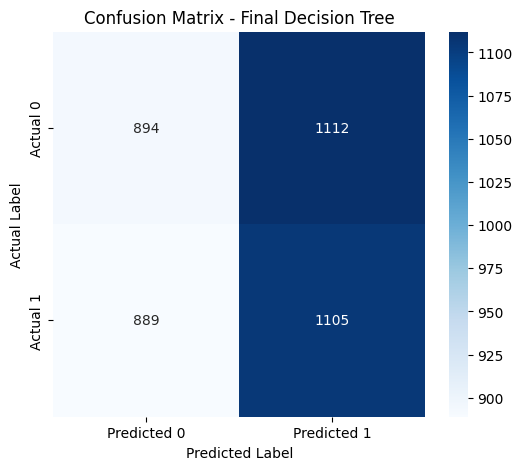

In [10]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted 0",
        "Predicted 1"
    ],
    yticklabels=[
        "Actual 0",
        "Actual 1"
    ]
)

plt.title("Confusion Matrix - Final Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


10. EXTRACT TN, FP, FN, TP

In [11]:
TN, FP, FN, TP = cm.ravel()

print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)


True Negative : 894
False Positive: 1112
False Negative: 889
True Positive : 1105


11. ROC CURVE

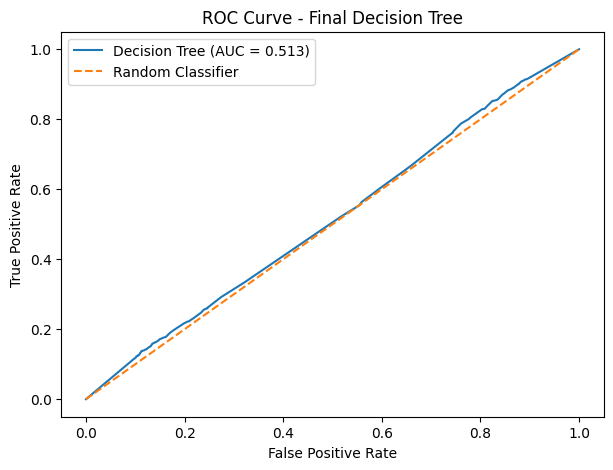

In [12]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Decision Tree")

plt.legend()

plt.show()



12. ERROR ANALYSIS

In [13]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred

error_analysis["Correct"] = (
    error_analysis["Actual"] ==
    error_analysis["Predicted"]
)

False Positives

In [14]:
false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]


False Negatives

In [15]:
false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]


print("\nError Analysis")
print("--------------------------------")

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))



Error Analysis
--------------------------------
False Positives: 1112
False Negatives: 889


 13. FALSE POSITIVE FEATURE ANALYSIS

In [16]:

print("\nFalse Positive Feature Means:")
display(
    false_positives[features].mean()
)



False Positive Feature Means:


Temperature           102.959033
Vibration               2.480504
Pressure              198.854568
Flow_Rate               9.996568
RPM                  1900.986392
Operational_Hours    4940.923035
dtype: float64

 14. FALSE NEGATIVE FEATURE ANALYSIS

In [17]:
print("\nFalse Negative Feature Means:")
display(
    false_negatives[features].mean()
)


False Negative Feature Means:


Temperature            98.227406
Vibration               2.657881
Pressure              201.175002
Flow_Rate              10.692015
RPM                  2153.716826
Operational_Hours    5149.321968
dtype: float64

15. CORRECT PREDICTION FEATURE MEANS

In [18]:
correct_predictions = error_analysis[
    error_analysis["Correct"]
]

print("\nCorrect Prediction Feature Means:")
display(
    correct_predictions[features].mean()
)


Correct Prediction Feature Means:


Temperature           100.689952
Vibration               2.565620
Pressure              199.138871
Flow_Rate              10.221910
RPM                  2007.959475
Operational_Hours    4932.104142
dtype: float64

16. ERROR COUNTS


In [19]:
total_errors = (
    len(false_positives) +
    len(false_negatives)
)

error_percentage = (
    total_errors /
    len(X_test) *
    100
)

print("\nTotal Errors:", total_errors)

print(
    f"Error Percentage: {error_percentage:.2f}%"
)



Total Errors: 2001
Error Percentage: 50.02%


 17. FINAL MODEL SUMMARY

In [20]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("\nFinal Model Evaluation Summary")
display(evaluation_summary)




Final Model Evaluation Summary


,Metric,Value
0,Accuracy,0.499750
1,Precision,0.498421
2,Recall,0.554162
3,F1-score,0.524816
4,ROC-AUC,0.513047


18. FINAL INTERPRETATION

In [21]:
print("""
FINAL INTERPRETATION
---------------------

The Decision Tree with max_depth=20 was selected as the final
foundational model after cross-validation during model development.

The model achieved approximately 50% accuracy and an ROC-AUC
close to 0.5 on the held-out test set.

This indicates that the available sensor and operational variables
provide limited predictive discrimination for the Maintenance_Flag
target in this dataset.

Therefore, the model should be presented as an educational
prototype and not as a reliable production maintenance predictor.
""")


FINAL INTERPRETATION
---------------------

The Decision Tree with max_depth=20 was selected as the final
foundational model after cross-validation during model development.

The model achieved approximately 50% accuracy and an ROC-AUC
close to 0.5 on the held-out test set.

This indicates that the available sensor and operational variables
provide limited predictive discrimination for the Maintenance_Flag
target in this dataset.

Therefore, the model should be presented as an educational
prototype and not as a reliable production maintenance predictor.

